# **MNIST Handwritten Digit Classification using Fully Connected Neural Network (MLP)**

## Assignment 1

**Implement** a fully connected neural network (MLP) using PyTorch to classify the MNIST handwritten digit dataset.



---
##  Import Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split

import numpy as np
import matplotlib.pyplot as plt
import time
import copy

from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check for GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4



##  Load and Preprocess MNIST Dataset

**Preprocessing steps:**
- Flatten each 28x28 image into a 784-dimensional vector
- Normalize pixel values to [0, 1] range
- Split into train (50,000), validation (10,000), and test (10,000) sets

In [3]:
# Define transforms: Convert to tensor and normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

# Download MNIST dataset
train_dataset_full = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Split training data into train and validation sets (50,000 train, 10,000 validation)
train_size = 50000
val_size = 10000
train_dataset, val_dataset = random_split(train_dataset_full, [train_size, val_size],
                                          generator=torch.Generator().manual_seed(42))

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"\nImage shape: 28x28 = 784 features (flattened)")
print(f"Number of classes: 10 (digits 0-9)")

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.90MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.20MB/s]

Training samples: 50000
Validation samples: 10000
Test samples: 10000

Image shape: 28x28 = 784 features (flattened)
Number of classes: 10 (digits 0-9)


###  Visualize Sample Images

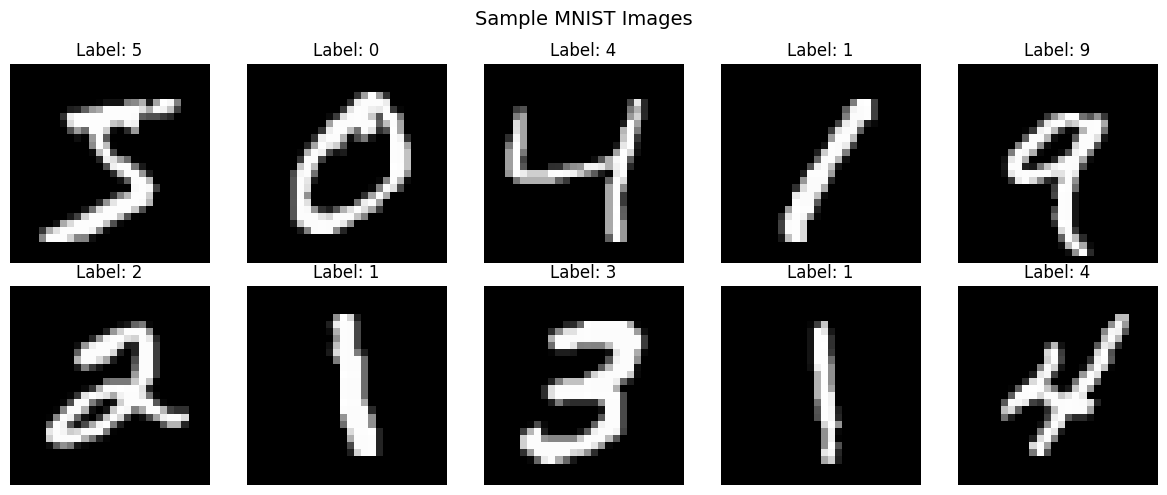

In [4]:
# Visualize some sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for idx, ax in enumerate(axes.flatten()):
    image, label = train_dataset_full[idx]
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(f'Label: {label}')
    ax.axis('off')
plt.suptitle('Sample MNIST Images', fontsize=14)
plt.tight_layout()
plt.show()

###  Create Data Loaders

In [5]:
# Create DataLoaders
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Batch size: {batch_size}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Batch size: 128
Training batches: 391
Validation batches: 79
Test batches: 79



##  Define MLP Model Architecture

For different(by changing activation function, learning rate, layer....) type of experiment We create a flexible MLP class that allows experimentation with:
- Different numbers of hidden layers
- Different neurons per layer
- Different activation functions
- Dropout for regularization
- Batch normalization for stable training

In [59]:
class MLP(nn.Module):
    """
        input_size: Number of input features (784)
        hidden_sizes: List of hidden layer sizes
        num_classes: Number of output classes (10)
        activation: Activation function ('relu', 'leaky_relu', 'elu', 'selu', 'gelu')
        dropout_rate: Dropout probability for regularization
        use_batch_norm: Whether to use batch normalization
    """
    def __init__(self, input_size=784, hidden_sizes=[512, 256, 128], num_classes=10,
                 activation='relu', dropout_rate=0.2, use_batch_norm=True):
        super(MLP, self).__init__()

        # Store configuration
        self.config = {
            'hidden_sizes': hidden_sizes,
            'activation': activation,
            'dropout_rate': dropout_rate,
            'use_batch_norm': use_batch_norm
        }

        # Select activation function
        activation_functions = {
            'relu': nn.ReLU(),
            'leaky_relu': nn.LeakyReLU(0.1),
            'elu': nn.ELU(),
            'selu': nn.SELU(),
            'gelu': nn.GELU()
        }
        self.activation = activation_functions.get(activation, nn.ReLU())

        # Build layers
        layers = []
        prev_size = input_size

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            if use_batch_norm:
                layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(self.activation)
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            prev_size = hidden_size

        # Output layer
        layers.append(nn.Linear(prev_size, num_classes))

        self.network = nn.Sequential(*layers)

        # Initialize weights
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # Flatten the input
        x = x.view(x.size(0), -1)
        return self.network(x)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# Test the model
test_model = MLP()
print(f"Model Architecture:")
print(test_model)
print(f"\nTotal trainable parameters: {test_model.count_parameters():,}")

Model Architecture:
MLP(
  (activation): ReLU()
  (network): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total trainable parameters: 569,226



## Training and Evaluation Functions

In [6]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler=None,
                num_epochs=50, device='cuda', early_stopping_patience=10):
    """
    Train the model with early stopping and learning rate scheduling.

    Returns:
        model: Trained model (best weights)
        history: Dictionary containing training history
    """
    model = model.to(device)

    # History tracking
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': [],
        'lr': []
    }

    best_val_acc = 0.0
    best_model_weights = copy.deepcopy(model.state_dict())
    patience_counter = 0

    start_time = time.time()

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()

            # Gradient clipping for stability
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            train_loss += loss.item() * data.size(0)
            _, predicted = output.max(1)
            train_total += target.size(0)
            train_correct += predicted.eq(target).sum().item()

        train_loss /= train_total
        train_acc = 100. * train_correct / train_total

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                loss = criterion(output, target)

                val_loss += loss.item() * data.size(0)
                _, predicted = output.max(1)
                val_total += target.size(0)
                val_correct += predicted.eq(target).sum().item()

        val_loss /= val_total
        val_acc = 100. * val_correct / val_total

        # Learning rate scheduling
        current_lr = optimizer.param_groups[0]['lr']
        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        # Record history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)

        # Check for best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        # Print progress every 5 epochs
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'Epoch [{epoch+1:3d}/{num_epochs}] | '
                  f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | '
                  f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | '
                  f'LR: {current_lr:.6f}')

        # Early stopping
        if patience_counter >= early_stopping_patience:
            print(f'\nEarly stopping at epoch {epoch+1}')
            break

    # Load best model weights
    model.load_state_dict(best_model_weights)

    total_time = time.time() - start_time
    print(f'\nTraining completed in {total_time:.2f}s')
    print(f'Best Validation Accuracy: {best_val_acc:.2f}%')

    return model, history

In [7]:
def evaluate_model(model, test_loader, device='cuda'):
    """
    Evaluate the model on test set and return detailed metrics.

    Returns:
        metrics: Dictionary containing accuracy, precision, recall, f1-score
        all_preds: All predictions
        all_targets: All true labels
    """
    model.eval()
    model = model.to(device)

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            _, predicted = output.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)

    # Calculate metrics
    metrics = {
        'accuracy': accuracy_score(all_targets, all_preds) * 100,
        'precision': precision_score(all_targets, all_preds, average='weighted') * 100,
        'recall': recall_score(all_targets, all_preds, average='weighted') * 100,
        'f1_score': f1_score(all_targets, all_preds, average='weighted') * 100
    }

    return metrics, all_preds, all_targets

In [8]:
def plot_training_history(history, title='Training History'):
    """
    Plot training vs validation loss and accuracy curves.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss plot
    axes[0].plot(history['train_loss'], label='Training Loss', linewidth=2)
    axes[0].plot(history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training vs Validation Loss', fontsize=14)
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    # Accuracy plot
    axes[1].plot(history['train_acc'], label='Training Accuracy', linewidth=2)
    axes[1].plot(history['val_acc'], label='Validation Accuracy', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy (%)', fontsize=12)
    axes[1].set_title('Training vs Validation Accuracy', fontsize=14)
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [9]:
def plot_confusion_matrix(targets, predictions, title='Confusion Matrix'):
    """
    Plot confusion matrix for the predictions.
    """
    cm = confusion_matrix(targets, predictions)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=range(10), yticklabels=range(10))
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.title(title, fontsize=14)
    plt.tight_layout()
    plt.show()


##  Experiment Configurations

Best(Best Test Accuracy) 5 Experiment configurations:

| Experiment | Hidden Layers | Activation | Optimizer | Learning Rate | Dropout |
|------------|---------------|------------|-----------|---------------|----------|
| 1 | [512, 256, 128] | ReLU | Adam | 0.001 | 0.2 |
| 2 | [1024, 512, 256, 128] | ReLU | Adam | 0.001 | 0.3 |
| 3 | [1024, 512, 256, 128] | GELU | AdamW | 0.001 | 0.2 |
| 4 | [2048, 1024, 512, 256] | GELU | AdamW | 0.0005 | 0.3 |
| 5  | [2048, 1024, 512, 256, 128] | GELU | AdamW | 0.001 | 0.25 |

In [12]:
# Define experiment configurations
experiments = {
    'Experiment 1 ': {
        'hidden_sizes': [512, 256, 128],
        'activation': 'relu',
        'dropout_rate': 0.2,
        'optimizer': 'Adam',
        'lr': 0.001,
        'weight_decay': 1e-4,
        'batch_norm': True
    },
    'Experiment 2 ': {
        'hidden_sizes': [1024, 512, 256, 128],
        'activation': 'relu',
        'dropout_rate': 0.3,
        'optimizer': 'Adam',
        'lr': 0.001,
        'weight_decay': 1e-4,
        'batch_norm': True
    },
    'Experiment 3 ': {
        'hidden_sizes': [1024, 512, 256, 128],
        'activation': 'gelu',
        'dropout_rate': 0.2,
        'optimizer': 'AdamW',
        'lr': 0.001,
        'weight_decay': 1e-3,
        'batch_norm': True
    },
    'Experiment 4 ': {
        'hidden_sizes': [2048, 1024, 512, 256],
        'activation': 'gelu',
        'dropout_rate': 0.3,
        'optimizer': 'AdamW',
        'lr': 0.0005,
        'weight_decay': 1e-3,
        'batch_norm': True
    },
    'Experiment 5 ': {
        'hidden_sizes': [2048, 1024, 512, 256, 128],
        'activation': 'gelu',
        'dropout_rate': 0.25,
        'optimizer': 'AdamW',
        'lr': 0.001,
        'weight_decay': 5e-4,
        'batch_norm': True
    }
}

print("Experiment Configurations:")

for name, config in experiments.items():
    print(f"\n{name}:")
    for key, value in config.items():
        print(f"  {key}: {value}")

Experiment Configurations:

Experiment 1 :
  hidden_sizes: [512, 256, 128]
  activation: relu
  dropout_rate: 0.2
  optimizer: Adam
  lr: 0.001
  weight_decay: 0.0001
  batch_norm: True

Experiment 2 :
  hidden_sizes: [1024, 512, 256, 128]
  activation: relu
  dropout_rate: 0.3
  optimizer: Adam
  lr: 0.001
  weight_decay: 0.0001
  batch_norm: True

Experiment 3 :
  hidden_sizes: [1024, 512, 256, 128]
  activation: gelu
  dropout_rate: 0.2
  optimizer: AdamW
  lr: 0.001
  weight_decay: 0.001
  batch_norm: True

Experiment 4 :
  hidden_sizes: [2048, 1024, 512, 256]
  activation: gelu
  dropout_rate: 0.3
  optimizer: AdamW
  lr: 0.0005
  weight_decay: 0.001
  batch_norm: True

Experiment 5 :
  hidden_sizes: [2048, 1024, 512, 256, 128]
  activation: gelu
  dropout_rate: 0.25
  optimizer: AdamW
  lr: 0.001
  weight_decay: 0.0005
  batch_norm: True



##  Run Experiments

In [15]:
def run_experiment(name, config, train_loader, val_loader, test_loader,
                   num_epochs=50, device='cuda'):
    """
    Run a single experiment with the given configuration.
    """
    print(f"\n{'='*80}")
    print(f"Running: {name}")
    print(f"{'='*80}")

    # Create model
    model = MLP(
        input_size=784,
        hidden_sizes=config['hidden_sizes'],
        num_classes=10,
        activation=config['activation'],
        dropout_rate=config['dropout_rate'],
        use_batch_norm=config['batch_norm']
    )

    print(f"Total parameters: {model.count_parameters():,}")

    # Create optimizer
    if config['optimizer'] == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=config['lr'],
                               weight_decay=config['weight_decay'])
    elif config['optimizer'] == 'AdamW':
        optimizer = optim.AdamW(model.parameters(), lr=config['lr'],
                                weight_decay=config['weight_decay'])
    elif config['optimizer'] == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=config['lr'],
                              momentum=0.9, weight_decay=config['weight_decay'])

    # Learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

    # Loss function
    criterion = nn.CrossEntropyLoss()

    # Train model
    model, history = train_model(
        model, train_loader, val_loader, criterion, optimizer, scheduler,
        num_epochs=num_epochs, device=device, early_stopping_patience=15
    )

    # Evaluate on test set
    metrics, predictions, targets = evaluate_model(model, test_loader, device)

    print(f"\n--- Test Set Results for {name} ---")
    print(f"Accuracy:  {metrics['accuracy']:.2f}%")
    print(f"Precision: {metrics['precision']:.2f}%")
    print(f"Recall:    {metrics['recall']:.2f}%")
    print(f"F1-Score:  {metrics['f1_score']:.2f}%")

    return model, history, metrics, predictions, targets


Running: Experiment 1 
Total parameters: 569,226
Epoch [  1/50] | Train Loss: 0.2922 | Train Acc: 91.16% | Val Loss: 0.1224 | Val Acc: 96.21% | LR: 0.001000
Epoch [  5/50] | Train Loss: 0.0677 | Train Acc: 97.87% | Val Loss: 0.0771 | Val Acc: 97.58% | LR: 0.001000
Epoch [ 10/50] | Train Loss: 0.0432 | Train Acc: 98.64% | Val Loss: 0.0723 | Val Acc: 97.93% | LR: 0.001000
Epoch [ 15/50] | Train Loss: 0.0354 | Train Acc: 98.84% | Val Loss: 0.0616 | Val Acc: 98.25% | LR: 0.001000
Epoch [ 20/50] | Train Loss: 0.0311 | Train Acc: 99.00% | Val Loss: 0.0670 | Val Acc: 98.03% | LR: 0.001000
Epoch [ 25/50] | Train Loss: 0.0129 | Train Acc: 99.59% | Val Loss: 0.0658 | Val Acc: 98.32% | LR: 0.000500
Epoch [ 30/50] | Train Loss: 0.0088 | Train Acc: 99.74% | Val Loss: 0.0573 | Val Acc: 98.41% | LR: 0.000250
Epoch [ 35/50] | Train Loss: 0.0063 | Train Acc: 99.82% | Val Loss: 0.0548 | Val Acc: 98.59% | LR: 0.000250
Epoch [ 40/50] | Train Loss: 0.0073 | Train Acc: 99.78% | Val Loss: 0.0593 | Val Acc: 

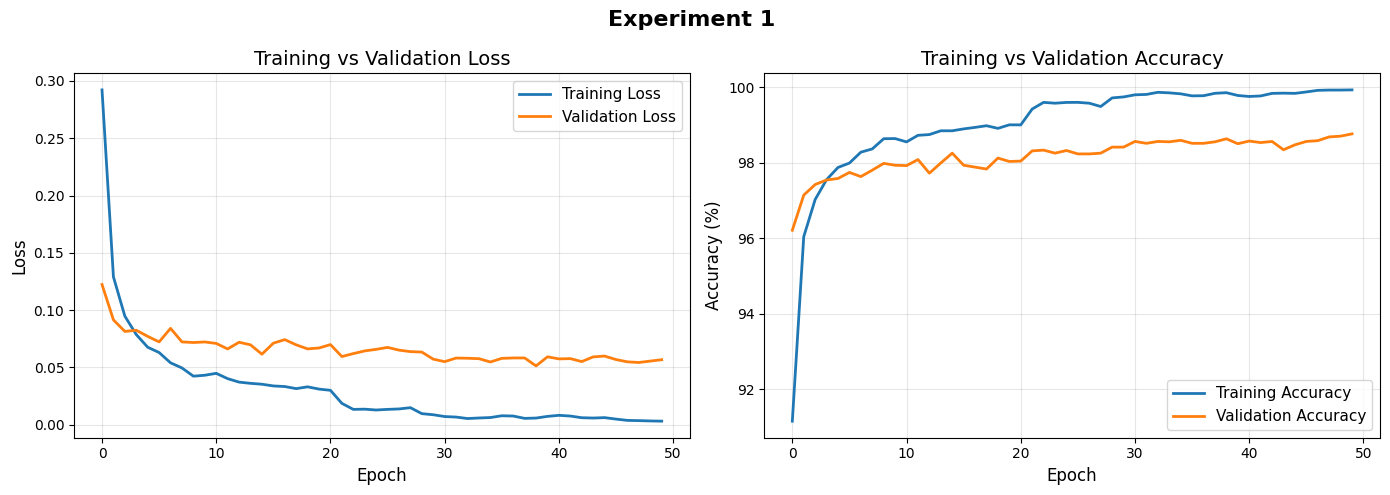


Running: Experiment 2 
Total parameters: 1,497,994
Epoch [  1/50] | Train Loss: 0.3469 | Train Acc: 89.45% | Val Loss: 0.1353 | Val Acc: 95.98% | LR: 0.001000
Epoch [  5/50] | Train Loss: 0.0893 | Train Acc: 97.26% | Val Loss: 0.0788 | Val Acc: 97.58% | LR: 0.001000
Epoch [ 10/50] | Train Loss: 0.0618 | Train Acc: 98.10% | Val Loss: 0.0743 | Val Acc: 97.89% | LR: 0.001000
Epoch [ 15/50] | Train Loss: 0.0551 | Train Acc: 98.33% | Val Loss: 0.0662 | Val Acc: 97.99% | LR: 0.001000
Epoch [ 20/50] | Train Loss: 0.0494 | Train Acc: 98.51% | Val Loss: 0.0748 | Val Acc: 97.74% | LR: 0.001000
Epoch [ 25/50] | Train Loss: 0.0449 | Train Acc: 98.61% | Val Loss: 0.0755 | Val Acc: 97.90% | LR: 0.001000
Epoch [ 30/50] | Train Loss: 0.0227 | Train Acc: 99.28% | Val Loss: 0.0572 | Val Acc: 98.34% | LR: 0.000500
Epoch [ 35/50] | Train Loss: 0.0232 | Train Acc: 99.31% | Val Loss: 0.0671 | Val Acc: 98.29% | LR: 0.000500
Epoch [ 40/50] | Train Loss: 0.0109 | Train Acc: 99.66% | Val Loss: 0.0584 | Val Acc

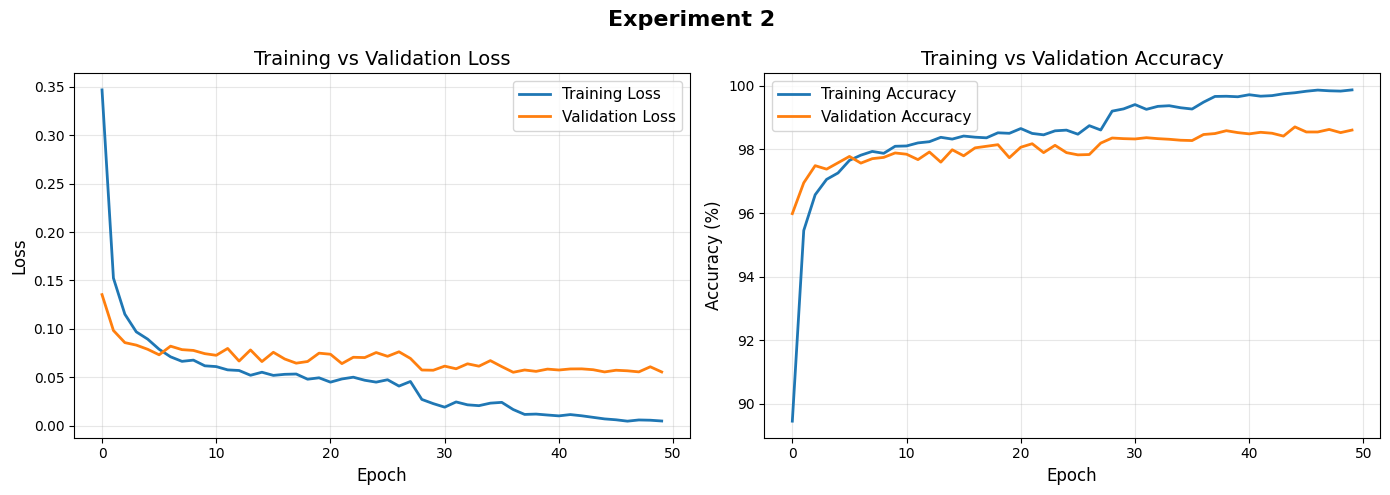


Running: Experiment 3 
Total parameters: 1,497,994
Epoch [  1/50] | Train Loss: 0.2469 | Train Acc: 92.73% | Val Loss: 0.1080 | Val Acc: 96.60% | LR: 0.001000
Epoch [  5/50] | Train Loss: 0.0512 | Train Acc: 98.37% | Val Loss: 0.0782 | Val Acc: 97.59% | LR: 0.001000
Epoch [ 10/50] | Train Loss: 0.0278 | Train Acc: 99.11% | Val Loss: 0.0675 | Val Acc: 98.11% | LR: 0.001000
Epoch [ 15/50] | Train Loss: 0.0186 | Train Acc: 99.40% | Val Loss: 0.0930 | Val Acc: 97.77% | LR: 0.001000
Epoch [ 20/50] | Train Loss: 0.0060 | Train Acc: 99.80% | Val Loss: 0.0652 | Val Acc: 98.40% | LR: 0.000500
Epoch [ 25/50] | Train Loss: 0.0032 | Train Acc: 99.90% | Val Loss: 0.0643 | Val Acc: 98.51% | LR: 0.000250
Epoch [ 30/50] | Train Loss: 0.0014 | Train Acc: 99.96% | Val Loss: 0.0654 | Val Acc: 98.61% | LR: 0.000125
Epoch [ 35/50] | Train Loss: 0.0011 | Train Acc: 99.96% | Val Loss: 0.0670 | Val Acc: 98.67% | LR: 0.000125
Epoch [ 40/50] | Train Loss: 0.0009 | Train Acc: 99.99% | Val Loss: 0.0652 | Val Acc

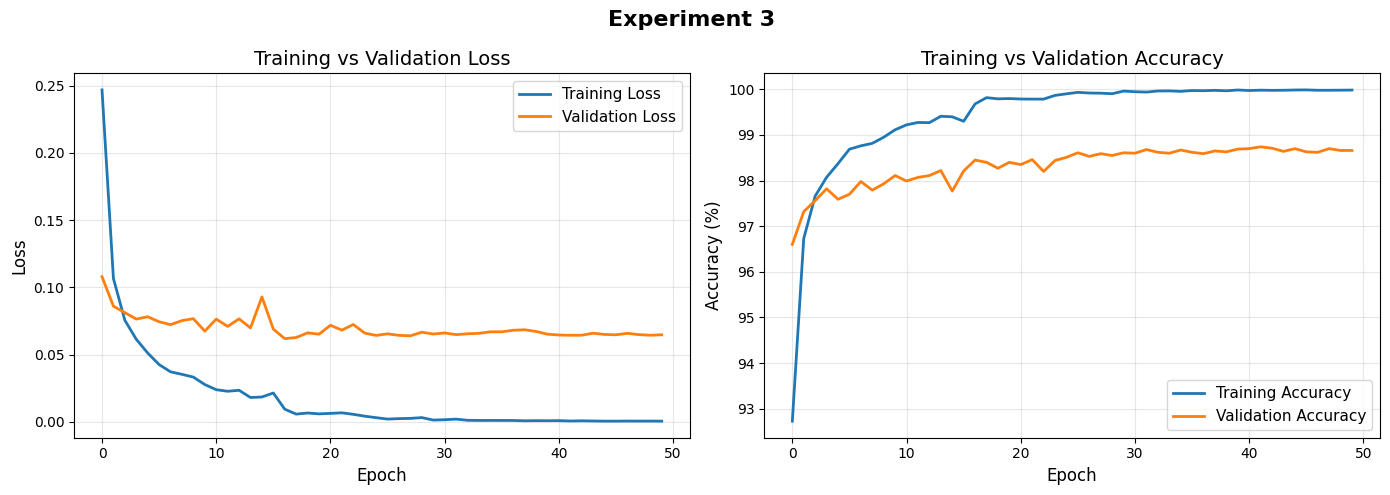


Running: Experiment 4 
Total parameters: 4,372,234
Epoch [  1/50] | Train Loss: 0.2682 | Train Acc: 91.80% | Val Loss: 0.1055 | Val Acc: 96.52% | LR: 0.000500
Epoch [  5/50] | Train Loss: 0.0500 | Train Acc: 98.38% | Val Loss: 0.0793 | Val Acc: 97.76% | LR: 0.000500
Epoch [ 10/50] | Train Loss: 0.0293 | Train Acc: 99.02% | Val Loss: 0.0734 | Val Acc: 98.05% | LR: 0.000500
Epoch [ 15/50] | Train Loss: 0.0086 | Train Acc: 99.73% | Val Loss: 0.0607 | Val Acc: 98.51% | LR: 0.000250
Epoch [ 20/50] | Train Loss: 0.0087 | Train Acc: 99.69% | Val Loss: 0.0669 | Val Acc: 98.39% | LR: 0.000250
Epoch [ 25/50] | Train Loss: 0.0036 | Train Acc: 99.89% | Val Loss: 0.0658 | Val Acc: 98.39% | LR: 0.000125
Epoch [ 30/50] | Train Loss: 0.0020 | Train Acc: 99.94% | Val Loss: 0.0659 | Val Acc: 98.55% | LR: 0.000063
Epoch [ 35/50] | Train Loss: 0.0015 | Train Acc: 99.96% | Val Loss: 0.0623 | Val Acc: 98.56% | LR: 0.000031
Epoch [ 40/50] | Train Loss: 0.0011 | Train Acc: 99.97% | Val Loss: 0.0641 | Val Acc

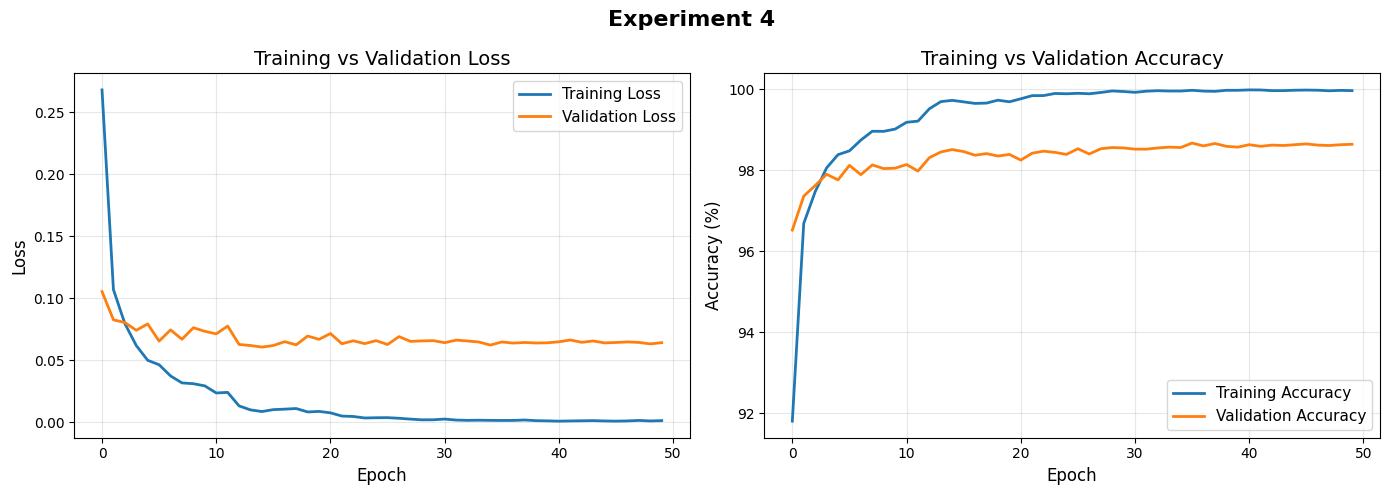


Running: Experiment 5 
Total parameters: 4,404,106
Epoch [  1/50] | Train Loss: 0.2563 | Train Acc: 92.50% | Val Loss: 0.1216 | Val Acc: 96.47% | LR: 0.001000
Epoch [  5/50] | Train Loss: 0.0582 | Train Acc: 98.18% | Val Loss: 0.0774 | Val Acc: 97.70% | LR: 0.001000
Epoch [ 10/50] | Train Loss: 0.0319 | Train Acc: 98.98% | Val Loss: 0.0778 | Val Acc: 97.92% | LR: 0.001000
Epoch [ 15/50] | Train Loss: 0.0220 | Train Acc: 99.29% | Val Loss: 0.0749 | Val Acc: 97.97% | LR: 0.001000
Epoch [ 20/50] | Train Loss: 0.0066 | Train Acc: 99.80% | Val Loss: 0.0629 | Val Acc: 98.49% | LR: 0.000500
Epoch [ 25/50] | Train Loss: 0.0074 | Train Acc: 99.75% | Val Loss: 0.0729 | Val Acc: 98.41% | LR: 0.000500
Epoch [ 30/50] | Train Loss: 0.0022 | Train Acc: 99.93% | Val Loss: 0.0657 | Val Acc: 98.70% | LR: 0.000250
Epoch [ 35/50] | Train Loss: 0.0010 | Train Acc: 99.97% | Val Loss: 0.0658 | Val Acc: 98.67% | LR: 0.000125
Epoch [ 40/50] | Train Loss: 0.0009 | Train Acc: 99.97% | Val Loss: 0.0648 | Val Acc

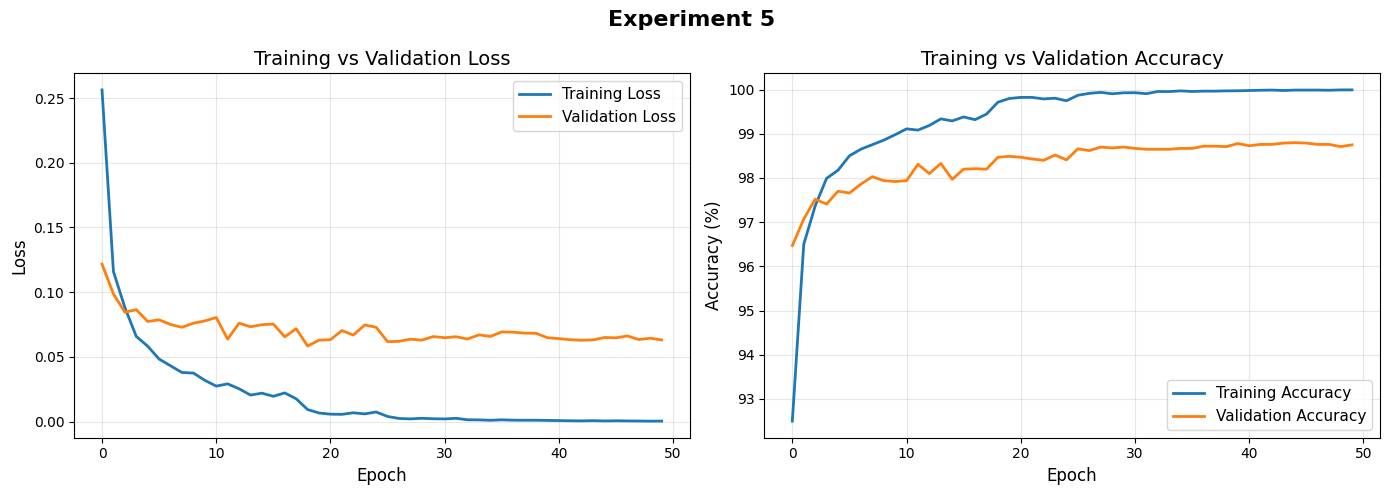

In [16]:
# Store results for all experiments
all_results = {}

# Run all experiments
for name, config in experiments.items():
    model, history, metrics, predictions, targets = run_experiment(
        name, config, train_loader, val_loader, test_loader,
        num_epochs=50, device=device
    )

    all_results[name] = {
        'model': model,
        'history': history,
        'metrics': metrics,
        'predictions': predictions,
        'targets': targets,
        'config': config
    }

    # Plot training history for each experiment
    plot_training_history(history, title=name)


##  Compare All Experiments

In [17]:
# Create comparison table

print("EXPERIMENT COMPARISON ")

print(f"{'Experiment':<35} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")


best_experiment = None
best_accuracy = 0

for name, result in all_results.items():
    metrics = result['metrics']
    print(f"{name:<35} {metrics['accuracy']:<12.2f} {metrics['precision']:<12.2f} "
          f"{metrics['recall']:<12.2f} {metrics['f1_score']:<12.2f}")

    if metrics['accuracy'] > best_accuracy:
        best_accuracy = metrics['accuracy']
        best_experiment = name


print(f"\n BEST  MODEL: {best_experiment}")
print(f"   Test Accuracy: {best_accuracy:.2f}%")

EXPERIMENT COMPARISON 
Experiment                          Accuracy     Precision    Recall       F1-Score    
Experiment 1                        98.75        98.75        98.75        98.75       
Experiment 2                        98.77        98.77        98.77        98.77       
Experiment 3                        98.74        98.74        98.74        98.74       
Experiment 4                        98.48        98.48        98.48        98.48       
Experiment 5                        98.70        98.70        98.70        98.70       

 BEST  MODEL: Experiment 2 
   Test Accuracy: 98.77%


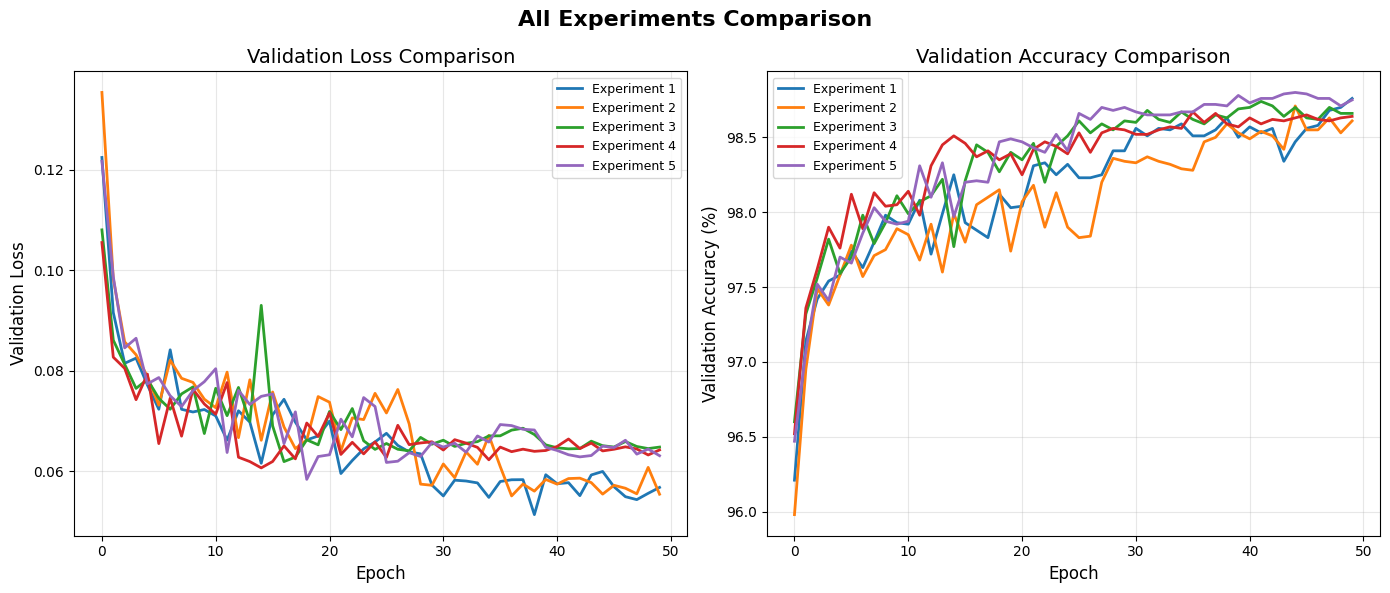

In [18]:
# Plot comparison of validation losses across experiments
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
for name, result in all_results.items():
    plt.plot(result['history']['val_loss'], label=name.split('(')[0].strip(), linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Loss', fontsize=12)
plt.title('Validation Loss Comparison', fontsize=14)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for name, result in all_results.items():
    plt.plot(result['history']['val_acc'], label=name.split('(')[0].strip(), linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Accuracy (%)', fontsize=12)
plt.title('Validation Accuracy Comparison', fontsize=14)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)

plt.suptitle('All Experiments Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

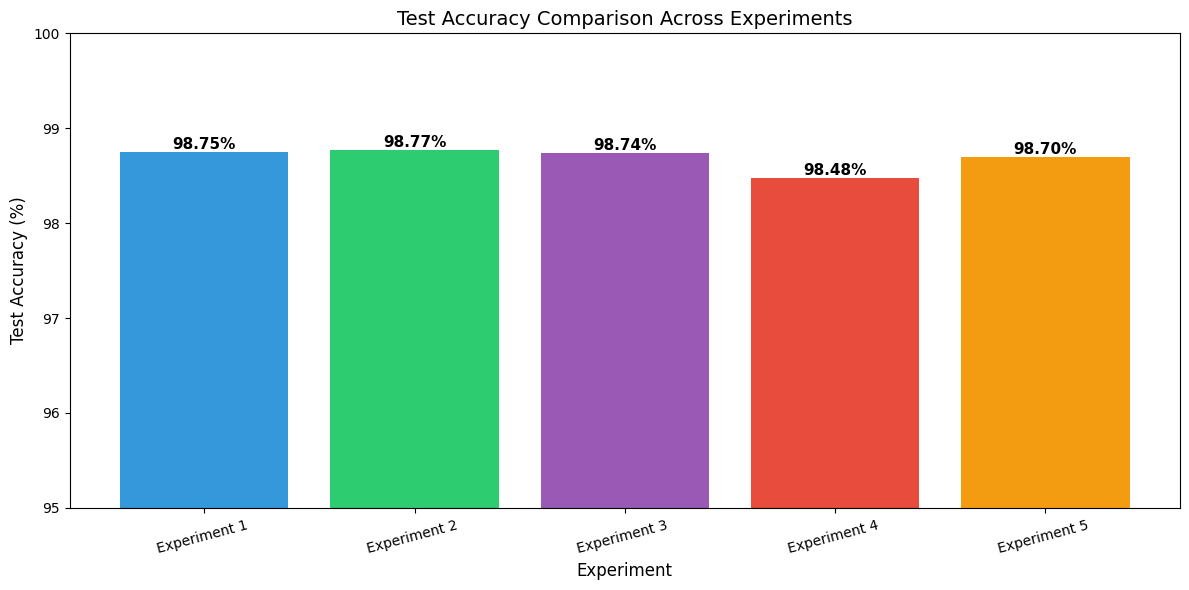

In [19]:
# Bar chart comparison of accuracies
fig, ax = plt.subplots(figsize=(12, 6))

experiment_names = [name.split('(')[1].replace(')', '') if '(' in name else name
                    for name in all_results.keys()]
accuracies = [result['metrics']['accuracy'] for result in all_results.values()]

bars = ax.bar(experiment_names, accuracies, color=['#3498db', '#2ecc71', '#9b59b6', '#e74c3c', '#f39c12'])
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_xlabel('Experiment', fontsize=12)
ax.set_title('Test Accuracy Comparison Across Experiments', fontsize=14)
ax.set_ylim([95, 100])

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


##  Detailed Analysis of Best Model

In [20]:
# Get best model results
best_result = all_results[best_experiment]


print(f"ANALYSIS OF BEST MODEL : {best_experiment}")


print("\n Model Configuration:")
for key, value in best_result['config'].items():
    print(f"   {key}: {value}")

print("\n Test Set Performance Metrics:")
print(f"   Accuracy:  {best_result['metrics']['accuracy']:.4f}%")
print(f"   Precision: {best_result['metrics']['precision']:.4f}%")
print(f"   Recall:    {best_result['metrics']['recall']:.4f}%")
print(f"   F1-Score:  {best_result['metrics']['f1_score']:.4f}%")

ANALYSIS OF BEST MODEL : Experiment 2 

 Model Configuration:
   hidden_sizes: [1024, 512, 256, 128]
   activation: relu
   dropout_rate: 0.3
   optimizer: Adam
   lr: 0.001
   weight_decay: 0.0001
   batch_norm: True

 Test Set Performance Metrics:
   Accuracy:  98.7700%
   Precision: 98.7700%
   Recall:    98.7700%
   F1-Score:  98.7698%


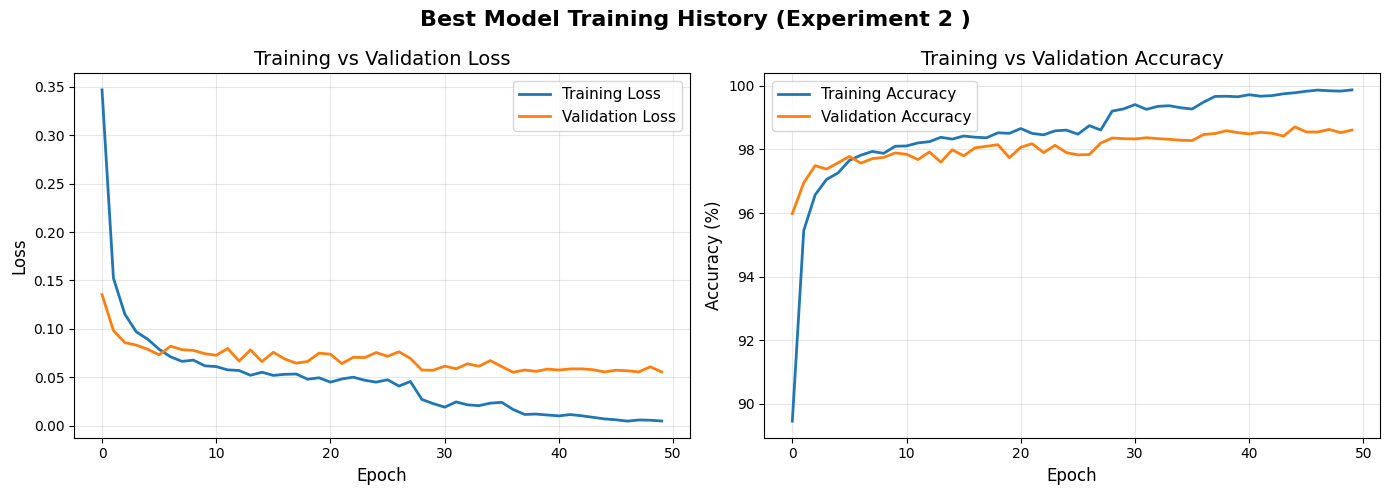

In [21]:
# Plot training history for best model
plot_training_history(best_result['history'],
                     title=f'Best Model Training History ({best_experiment})')

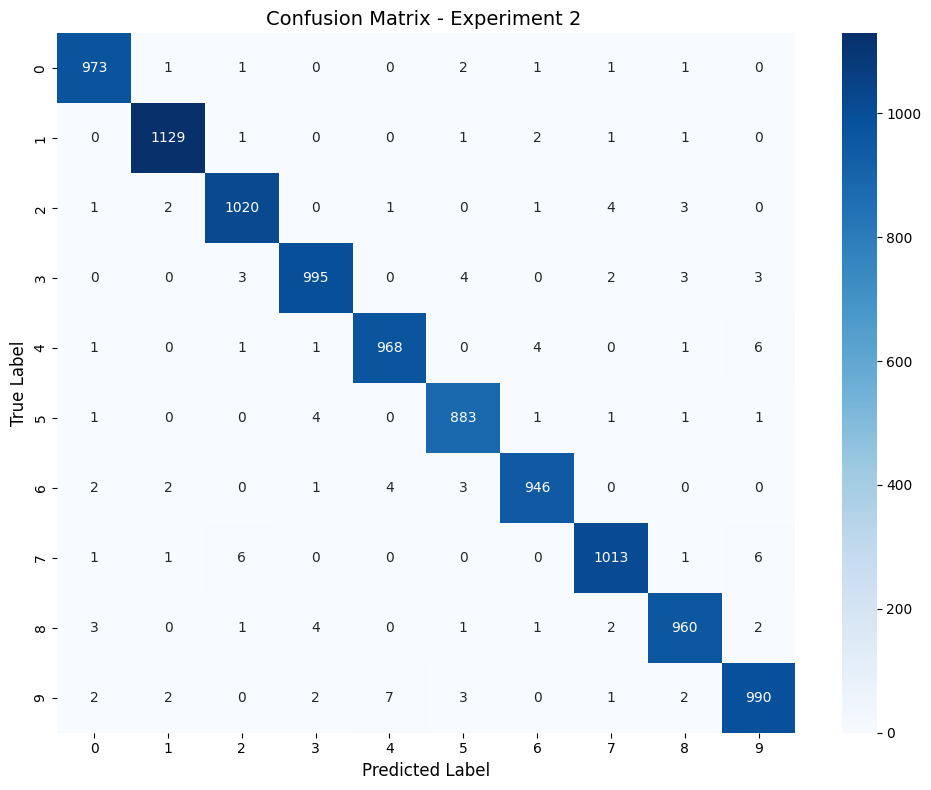

In [22]:
# Confusion matrix for best model
plot_confusion_matrix(best_result['targets'], best_result['predictions'],
                     title=f'Confusion Matrix - {best_experiment}')

In [23]:
# Per-class classification report
print("\n Per-Class Classification Report:")

print(classification_report(best_result['targets'], best_result['predictions'],
                           target_names=[f'Digit {i}' for i in range(10)]))


 Per-Class Classification Report:
              precision    recall  f1-score   support

     Digit 0       0.99      0.99      0.99       980
     Digit 1       0.99      0.99      0.99      1135
     Digit 2       0.99      0.99      0.99      1032
     Digit 3       0.99      0.99      0.99      1010
     Digit 4       0.99      0.99      0.99       982
     Digit 5       0.98      0.99      0.99       892
     Digit 6       0.99      0.99      0.99       958
     Digit 7       0.99      0.99      0.99      1028
     Digit 8       0.99      0.99      0.99       974
     Digit 9       0.98      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000




##  Misclassified Examples

Total misclassified samples: 123 out of 10000
Error rate: 1.23%


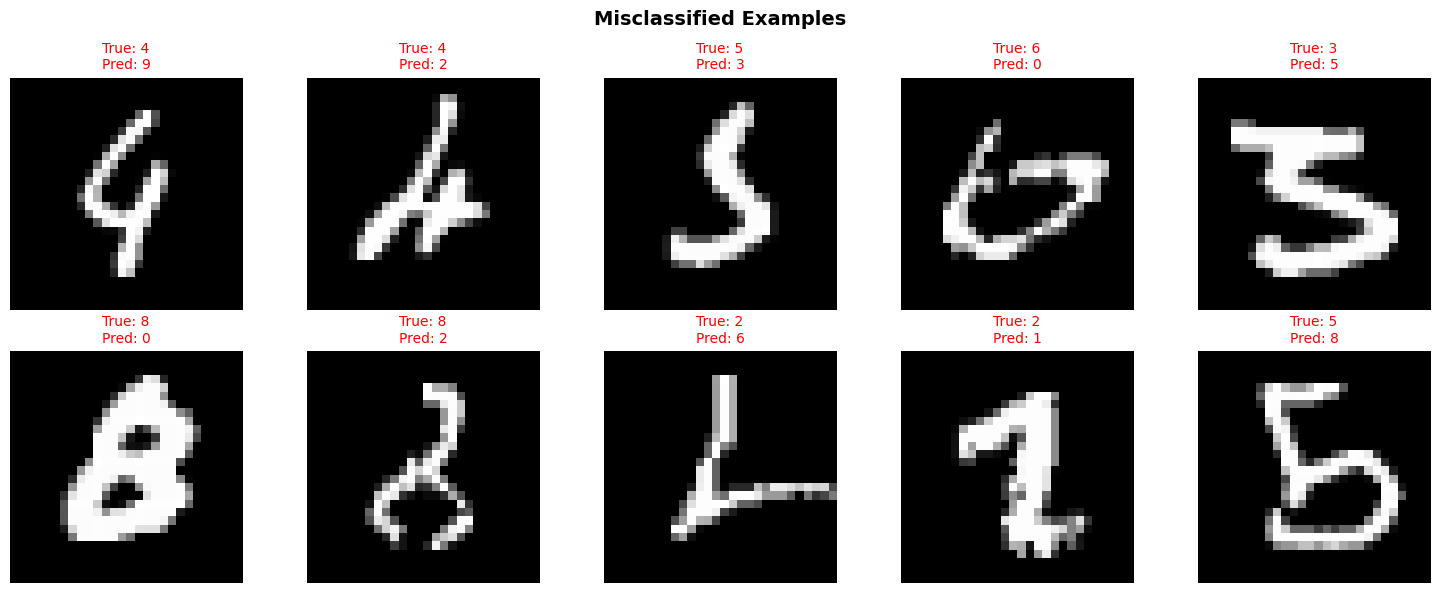

In [24]:
# Find misclassified examples
misclassified_indices = np.where(best_result['predictions'] != best_result['targets'])[0]
print(f"Total misclassified samples: {len(misclassified_indices)} out of {len(best_result['targets'])}")
print(f"Error rate: {len(misclassified_indices)/len(best_result['targets'])*100:.2f}%")

# Plot some misclassified examples
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for idx, ax in enumerate(axes.flatten()):
    if idx < len(misclassified_indices):
        sample_idx = misclassified_indices[idx]
        image, true_label = test_dataset[sample_idx]
        pred_label = best_result['predictions'][sample_idx]

        ax.imshow(image.squeeze(), cmap='gray')
        ax.set_title(f'True: {true_label}\nPred: {pred_label}', fontsize=10, color='red')
        ax.axis('off')

plt.suptitle('Misclassified Examples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Next Part: Saving and Testing Our Model

- Explore how our trained deep learning models actually work.  
- Save the trained models in `.pth` format using PyTorch.  
- This helps us store learned weights and reuse the models later.  
- The saved model files will be uploaded into a new environment.  
- Load the models back and run inference on test data.  
- This will show how the models behave on real inputs.  
- We will visualize the predictions for better understanding.  
- Compare predicted outputs with expected results.  
- This practical step helps evaluate real model performance.  
- I will take help from an LLM for guidance and debugging.  
  



---
##  Save Best Model

In [27]:
# Save the best performing model
torch.save({
    'model_state_dict': best_result['model'].state_dict(),
    'config': best_result['config'],
    'metrics': best_result['metrics']
}, 'best_mnist_mlp_model.pth')

print("Best model saved as 'best_mnist_mlp_model.pth'")

Best model saved as 'best_mnist_mlp_model.pth'


In [41]:
# Load the saved model
def load_model(model_path='best_mnist_mlp_model.pth'):
    """
    Load the trained model from checkpoint.
    """
    checkpoint = torch.load(model_path, map_location=device)
    config = checkpoint['config']

    # Create model with saved configuration
    model = MLP(
        input_size=784,
        hidden_sizes=config['hidden_sizes'],
        num_classes=10,
        activation=config['activation'],
        dropout_rate=config['dropout_rate'],
        use_batch_norm=config['batch_norm']
    )

    # Load weights
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()

    print(" Model loaded successfully!")
    print(f"   Configuration: {config['hidden_sizes']}")
    print(f"   Activation: {config['activation']}")
    print(f"   Saved Accuracy: {checkpoint['metrics']['accuracy']:.2f}%")

    return model

# Load the model
model = load_model('best_mnist_mlp_model.pth')

 Model loaded successfully!
   Configuration: [1024, 512, 256, 128]
   Activation: relu
   Saved Accuracy: 98.77%


In [42]:
def preprocess_image(image):
    """
    Preprocess an uploaded image for MNIST model prediction.

    Steps:
    1. Convert to grayscale
    2. Resize to 28x28
    3. Invert colors if needed (MNIST has white digit on black background)
    4. Normalize using MNIST mean and std
    5. Convert to tensor

    Args:
        image: PIL Image object

    Returns:
        tensor: Preprocessed image tensor ready for model
    """
    # Convert to grayscale
    image = image.convert('L')

    # Resize to 28x28
    image = image.resize((28, 28), Image.LANCZOS)

    # Convert to numpy array
    img_array = np.array(image, dtype=np.float32)

    # Check if we need to invert (MNIST expects white digit on black background)
    # If the image has more white than black, invert it
    if np.mean(img_array) > 127:
        img_array = 255 - img_array

    # Normalize to [0, 1]
    img_array = img_array / 255.0

    # Apply MNIST normalization (mean=0.1307, std=0.3081)
    img_array = (img_array - 0.1307) / 0.3081

    # Convert to tensor and add batch dimension
    tensor = torch.FloatTensor(img_array).unsqueeze(0).unsqueeze(0)

    return tensor, img_array

In [43]:
def predict_digit(model, image_tensor, device='cuda'):
    """
    Predict the digit from preprocessed image tensor.

    Returns:
        predicted_digit: The predicted digit (0-9)
        confidence: Confidence score for the prediction
        all_probs: Probabilities for all digits
    """
    model.eval()
    image_tensor = image_tensor.to(device)

    with torch.no_grad():
        output = model(image_tensor)
        probabilities = F.softmax(output, dim=1)
        confidence, predicted = torch.max(probabilities, 1)

    predicted_digit = predicted.item()
    confidence_score = confidence.item() * 100
    all_probs = probabilities.cpu().numpy().flatten() * 100

    return predicted_digit, confidence_score, all_probs

In [44]:
def predict_digit(model, image_tensor, device='cuda'):
    """
    Predict the digit from preprocessed image tensor.

    Returns:
        predicted_digit: The predicted digit (0-9)
        confidence: Confidence score for the prediction
        all_probs: Probabilities for all digits
    """
    model.eval()
    image_tensor = image_tensor.to(device)

    with torch.no_grad():
        output = model(image_tensor)
        probabilities = F.softmax(output, dim=1)
        confidence, predicted = torch.max(probabilities, 1)

    predicted_digit = predicted.item()
    confidence_score = confidence.item() * 100
    all_probs = probabilities.cpu().numpy().flatten() * 100

    return predicted_digit, confidence_score, all_probs

In [45]:
def display_prediction(original_image, processed_array, predicted_digit, confidence, all_probs):
    """
    Display the prediction results with visualization.
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Original image
    axes[0].imshow(original_image, cmap='gray')
    axes[0].set_title('Original Image', fontsize=12)
    axes[0].axis('off')

    # Processed image (28x28)
    axes[1].imshow(processed_array, cmap='gray')
    axes[1].set_title(f'Processed (28x28)\nPredicted: {predicted_digit}', fontsize=12)
    axes[1].axis('off')

    # Probability bar chart
    colors = ['green' if i == predicted_digit else 'steelblue' for i in range(10)]
    bars = axes[2].bar(range(10), all_probs, color=colors)
    axes[2].set_xlabel('Digit', fontsize=11)
    axes[2].set_ylabel('Probability (%)', fontsize=11)
    axes[2].set_title('Prediction Probabilities', fontsize=12)
    axes[2].set_xticks(range(10))
    axes[2].set_ylim([0, 100])

    # Add value labels on bars
    for bar, prob in zip(bars, all_probs):
        if prob > 5:
            axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                        f'{prob:.1f}%', ha='center', va='bottom', fontsize=9)

    plt.suptitle(f' Prediction: {predicted_digit} (Confidence: {confidence:.2f}%)',
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Print results

    print(f" PREDICTED DIGIT: {predicted_digit}")
    print(f" CONFIDENCE: {confidence:.2f}%")

    print("\nAll Probabilities:")
    for digit, prob in enumerate(all_probs):
        bar = '█' * int(prob/2) #U+2588
        print(f"  Digit {digit}: {prob:6.2f}% {bar}")

In [46]:
from google.colab import files
from PIL import Image
import io
import torch.nn.functional as F

 Please upload an image of a handwritten digit (0-9)
   Supported formats: PNG, JPG, JPEG, BMP


Saving Number 8 black and white.jpg to Number 8 black and white (7).jpg

 Uploaded: Number 8 black and white (7).jpg


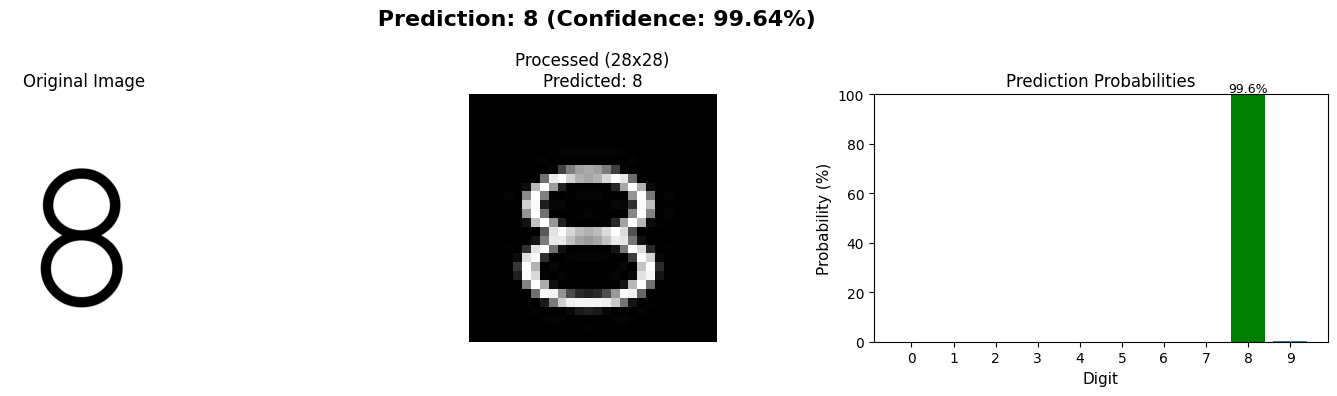

 PREDICTED DIGIT: 8
 CONFIDENCE: 99.64%

All Probabilities:
  Digit 0:   0.02% 
  Digit 1:   0.01% 
  Digit 2:   0.03% 
  Digit 3:   0.03% 
  Digit 4:   0.04% 
  Digit 5:   0.05% 
  Digit 6:   0.01% 
  Digit 7:   0.00% 
  Digit 8:  99.64% █████████████████████████████████████████████████
  Digit 9:   0.16% 


In [47]:
def upload_and_predict():
    """
    Main function to upload an image and get prediction.
    """
    print(" Please upload an image of a handwritten digit (0-9)")
    print("   Supported formats: PNG, JPG, JPEG, BMP")


    # Upload file
    uploaded = files.upload()

    for filename, content in uploaded.items():
        print(f"\n Uploaded: {filename}")

        # Open image
        image = Image.open(io.BytesIO(content))
        original_image = image.copy()

        # Preprocess
        image_tensor, processed_array = preprocess_image(image)

        # Predict
        predicted_digit, confidence, all_probs = predict_digit(model, image_tensor, device)

        # Display results
        display_prediction(original_image, processed_array, predicted_digit, confidence, all_probs)

# Run the upload and prediction
upload_and_predict()

 Please upload an image of a handwritten digit (0-9)
   Supported formats: PNG, JPG, JPEG, BMP


Saving Screenshot 2026-01-22 203749.png to Screenshot 2026-01-22 203749.png

 Uploaded: Screenshot 2026-01-22 203749.png


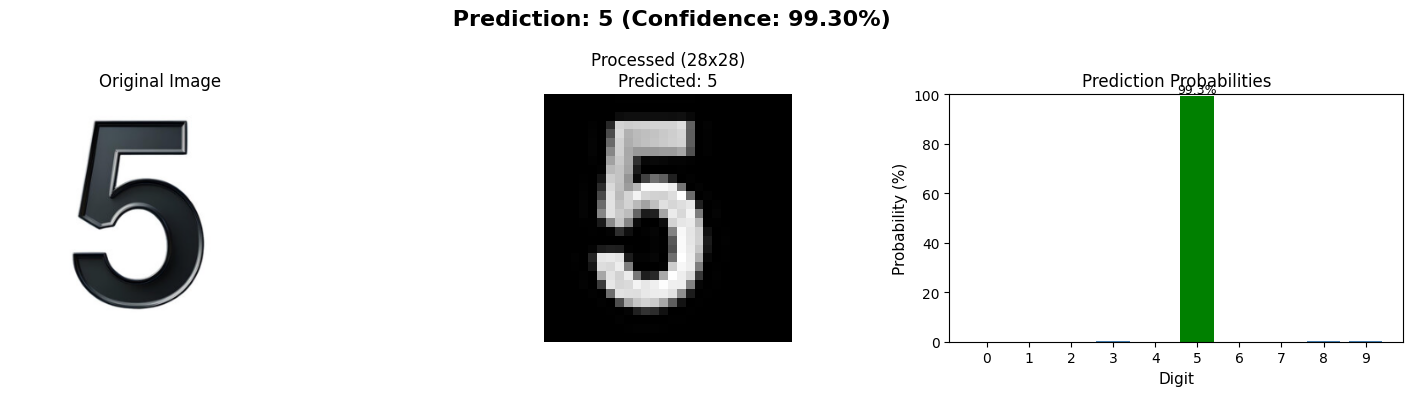

 PREDICTED DIGIT: 5
 CONFIDENCE: 99.30%

All Probabilities:
  Digit 0:   0.01% 
  Digit 1:   0.01% 
  Digit 2:   0.02% 
  Digit 3:   0.39% 
  Digit 4:   0.00% 
  Digit 5:  99.30% █████████████████████████████████████████████████
  Digit 6:   0.01% 
  Digit 7:   0.01% 
  Digit 8:   0.16% 
  Digit 9:   0.10% 


In [55]:
upload_and_predict()

 Please upload an image of a handwritten digit (0-9)
   Supported formats: PNG, JPG, JPEG, BMP


Saving Screenshot 2026-01-22 203833.png to Screenshot 2026-01-22 203833.png

 Uploaded: Screenshot 2026-01-22 203833.png


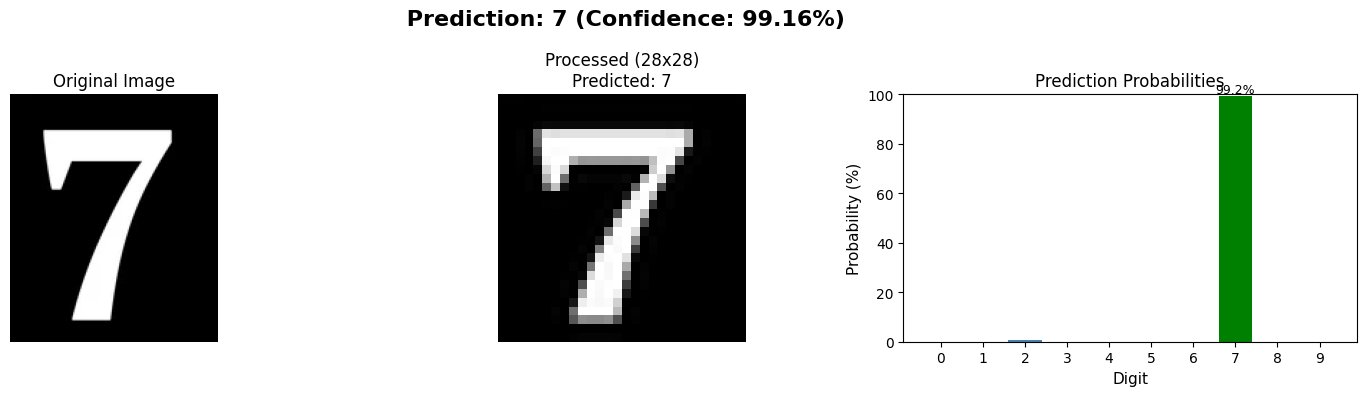

 PREDICTED DIGIT: 7
 CONFIDENCE: 99.16%

All Probabilities:
  Digit 0:   0.00% 
  Digit 1:   0.00% 
  Digit 2:   0.78% 
  Digit 3:   0.06% 
  Digit 4:   0.00% 
  Digit 5:   0.00% 
  Digit 6:   0.00% 
  Digit 7:  99.16% █████████████████████████████████████████████████
  Digit 8:   0.00% 
  Digit 9:   0.00% 


In [56]:
upload_and_predict()

 Please upload an image of a handwritten digit (0-9)
   Supported formats: PNG, JPG, JPEG, BMP


Saving Screenshot 2026-01-22 204115.png to Screenshot 2026-01-22 204115.png

 Uploaded: Screenshot 2026-01-22 204115.png


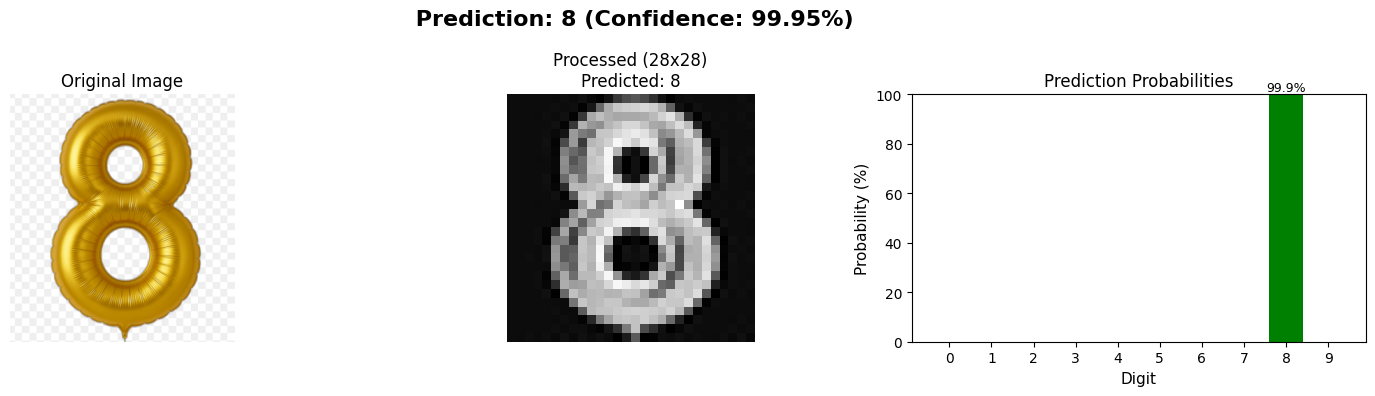

 PREDICTED DIGIT: 8
 CONFIDENCE: 99.95%

All Probabilities:
  Digit 0:   0.01% 
  Digit 1:   0.00% 
  Digit 2:   0.00% 
  Digit 3:   0.01% 
  Digit 4:   0.00% 
  Digit 5:   0.01% 
  Digit 6:   0.01% 
  Digit 7:   0.00% 
  Digit 8:  99.95% █████████████████████████████████████████████████
  Digit 9:   0.01% 


In [58]:
upload_and_predict()